# Multi-Session PCA Population Analysis

This notebook performs PCA analysis across ALL valid MSN recording sessions from Fiona, combining neural populations from multiple sessions to identify common latent structure in GO and STOP trial responses.

**Analysis Strategy:**
1. Load all sessions from MSN database
2. Filter sessions by quality criteria (exclude known bad sessions)
3. For each session: validate sufficient data for all trial types and directions
4. Drop cells with incomplete trial coverage within each session
5. Extract PSTH matrices from all sessions using consistent parameters
6. Concatenate PSTH matrices across sessions (cells from all sessions combined)
7. Run PCA on combined population
8. Visualize PC trajectories for GO and STOP trials
9. Track session contributions to understand cross-session generalization

**Key Differences from Single-Session Analysis:**
- No train/test split (use all data for maximum statistical power)
- Global normalization across ALL sessions
- Session identity tracked for post-hoc analysis
- Validation criteria applied per session before inclusion
- Parallel processing with ProcessPoolExecutor for speed

In [1]:
# Import dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
import sys
import warnings
warnings.filterwarnings('ignore')

# Add parent directory to path
sys.path.insert(0, str(Path.cwd().parent))
import importlib
import session_class
import cell_analysis
importlib.reload(session_class)
importlib.reload(cell_analysis)
from session_class import Session
from cell_analysis import Cell, PopulationAnalyzer

print("✓ Imports loaded successfully!")

✓ Imports loaded successfully!


In [2]:
# Analysis configuration
MONKEY = 'fiona'
EXCLUDED_SESSIONS = ['fi210628', 'fi210629', 'fi210704']  # Known bad sessions from CLAUDE.md

# PCA parameters
EPOK = [-50, 150]  # ms relative to go_cue
BIN_SIZE = 1  # ms
ALIGNMENT_POINT = 'go_cue'
SMOOTH_KER_SIZE = 15  # ms
NORMALIZE = 'by_baseline_FR'  # Normalization strategy (subtracts baseline FR from each cell)
N_PCA_COMPONENTS = 5

# Validation criteria for session inclusion
MIN_CELLS_PER_SESSION = 10  # Minimum neurons required
MIN_TRIALS_PER_CONDITION = 5  # Minimum trials per (trial_type, direction) combination

# Trial types and directions to validate
REQUIRED_TRIAL_TYPES = ['GO', 'STOP', 'CONT']
REQUIRED_DIRECTIONS = [0, 180]

# Visualization parameters
FIGSIZE_3D = (12, 10)
FIGSIZE_2D_GRID = (16, 14)
FIGSIZE_TIME = (16, 6)

print(f"✓ Configuration set for {MONKEY}")
print(f"  Epoch: {EPOK} ms")
print(f"  Excluded sessions: {EXCLUDED_SESSIONS}")
print(f"  Min cells per session: {MIN_CELLS_PER_SESSION}")
print(f"  Min trials per condition: {MIN_TRIALS_PER_CONDITION}")

✓ Configuration set for fiona
  Epoch: [-50, 150] ms
  Excluded sessions: ['fi210628', 'fi210629', 'fi210704']
  Min cells per session: 10
  Min trials per condition: 5


In [3]:
# Load MSN cell database
base_path = Path.cwd().parent / 'data' / 'unified_cell_trial_data' 
pickle_file = base_path / f'msn_{MONKEY}_cell_trial_data.pkl'

print(f"Loading data from: {pickle_file}")
cell_df = pd.read_pickle(pickle_file)

print(f"✓ Database loaded: {cell_df.shape[0]:,} cell-trial combinations")
print(f"  Columns: {cell_df.shape[1]}")
print(f"  Total sessions: {cell_df['trial_session'].nunique()}")
print(f"  Total unique cells: {cell_df['cell_ID'].nunique()}")

Loading data from: /Users/barak/Projects/population_analysis/data/unified_cell_trial_data/msn_fiona_cell_trial_data.pkl
✓ Database loaded: 770,705 cell-trial combinations
  Columns: 27
  Total sessions: 60
  Total unique cells: 1414
✓ Database loaded: 770,705 cell-trial combinations
  Columns: 27
  Total sessions: 60
  Total unique cells: 1414


In [4]:
# Get all sessions and their basic statistics
session_stats = []

for session_id in cell_df['trial_session'].unique():
    session_data = cell_df[cell_df['trial_session'] == session_id]
    
    n_cells = session_data['cell_ID'].nunique()
    n_trials = len(session_data['trial_number'].unique())
    trial_types = sorted(session_data['type'].unique())
    directions = sorted(session_data['dir'].dropna().unique())
    
    # Check exclusion list
    is_excluded = any(excl in session_id for excl in EXCLUDED_SESSIONS)
    
    session_stats.append({
        'session_id': session_id,
        'n_cells': n_cells,
        'n_trials': n_trials,
        'trial_types': trial_types,
        'directions': directions,
        'is_excluded': is_excluded
    })

session_stats_df = pd.DataFrame(session_stats)
session_stats_df = session_stats_df.sort_values('n_cells', ascending=False)

print(f"✓ Session statistics computed for {len(session_stats_df)} sessions")
print(f"\nTop 10 sessions by cell count:")
print(session_stats_df.head(10)[['session_id', 'n_cells', 'n_trials', 'is_excluded']])

print(f"\nExcluded sessions: {session_stats_df['is_excluded'].sum()}")
print(f"Candidate sessions (not excluded): {(~session_stats_df['is_excluded']).sum()}")

✓ Session statistics computed for 60 sessions

Top 10 sessions by cell count:
   session_id  n_cells  n_trials  is_excluded
45  fi211110a       85       943        False
11  fi211026a       76       838        False
57  fi211102a       71       748        False
8   fi211111a       64       985        False
44  fi211025a       63       685        False
22  fi211104a       59       834        False
39  fi211109a       59       920        False
31  fi211122a       58       944        False
26  fi211115a       53       960        False
10  fi211118a       52       960        False

Excluded sessions: 1
Candidate sessions (not excluded): 59


In [5]:
# Define validation function
def validate_session(session_data, session_id, min_cells=MIN_CELLS_PER_SESSION, 
                     min_trials=MIN_TRIALS_PER_CONDITION,
                     required_types=REQUIRED_TRIAL_TYPES,
                     required_dirs=REQUIRED_DIRECTIONS,
                     verbose=False):
    """
    Validate if a session meets criteria for PCA analysis.
    
    Returns:
        (is_valid, reason, n_cells_after_drop)
    """
    
    # Check 1: Sufficient cells before dropping
    n_cells_raw = session_data['cell_ID'].nunique()
    if n_cells_raw < min_cells:
        return False, f"Insufficient cells: {n_cells_raw} < {min_cells}", 0
    
    # Check 2: Has all required trial types
    present_types = set(session_data['type'].unique())
    if not set(required_types).issubset(present_types):
        missing = set(required_types) - present_types
        return False, f"Missing trial types: {missing}", 0
    
    # Check 3: Has all required directions
    present_dirs = set(session_data['dir'].dropna().unique())
    if not set(required_dirs).issubset(present_dirs):
        missing = set(required_dirs) - present_dirs
        return False, f"Missing directions: {missing}", 0
    
    # Check 4: Create Session object and drop incomplete cells
    try:
        session = Session(session_data, verbose=False)
        session.drop_cells_with_missing_trial_type_or_dir_data()
        n_cells_after_drop = len(session.cell_ids)
        
        if n_cells_after_drop < min_cells:
            return False, f"Too few cells after dropping incomplete: {n_cells_after_drop} < {min_cells}", n_cells_after_drop
            
    except Exception as e:
        return False, f"Session creation failed: {str(e)}", 0
    
    # Check 5: Sufficient trials per condition
    for trial_type in required_types:
        for direction in required_dirs:
            condition_data = session.data[
                (session.data['type'] == trial_type) & 
                (session.data['dir'] == direction) &
                (session.data['trial_failed'] == False)
            ]
            n_trials_condition = len(condition_data['trial_number'].unique())
            
            if n_trials_condition < min_trials:
                return False, f"Insufficient {trial_type} dir={direction} trials: {n_trials_condition} < {min_trials}", n_cells_after_drop
    
    if verbose:
        print(f"✓ {session_id}: {n_cells_after_drop} cells validated")
    
    return True, "Valid", n_cells_after_drop

print("✓ Validation function defined")

✓ Validation function defined


In [6]:
# Validate each session
validation_results = []

print("Validating sessions...")
print("-" * 80)

for _, row in session_stats_df.iterrows():
    session_id = row['session_id']
    
    # Skip excluded sessions
    if row['is_excluded']:
        validation_results.append({
            'session_id': session_id,
            'is_valid': False,
            'reason': 'In exclusion list',
            'n_cells': 0
        })
        print(f"⊗ {session_id}: EXCLUDED (in exclusion list)")
        continue
    
    # Get session data
    session_data = cell_df[cell_df['trial_session'] == session_id]
    
    # Validate
    is_valid, reason, n_cells = validate_session(session_data, session_id, verbose=False)
    
    validation_results.append({
        'session_id': session_id,
        'is_valid': is_valid,
        'reason': reason,
        'n_cells': n_cells
    })
    
    if is_valid:
        print(f"✓ {session_id}: Valid ({n_cells} cells)")
    else:
        print(f"✗ {session_id}: Invalid - {reason}")

validation_df = pd.DataFrame(validation_results)

print("-" * 80)
print(f"\n✓ Validation complete:")
print(f"  Valid sessions: {validation_df['is_valid'].sum()}")
print(f"  Invalid sessions: {(~validation_df['is_valid']).sum()}")
print(f"  Total cells in valid sessions: {validation_df[validation_df['is_valid']]['n_cells'].sum()}")

Validating sessions...
--------------------------------------------------------------------------------
Cell 2134 removed from session fi211110a.
Dropped 1 cell with incomplete trial type or directional data.
✓ fi211110a: Valid (84 cells)
Dropped 1 cell with incomplete trial type or directional data.
✓ fi211110a: Valid (84 cells)
✓ fi211026a: Valid (76 cells)
✓ fi211026a: Valid (76 cells)
✓ fi211102a: Valid (71 cells)
✓ fi211102a: Valid (71 cells)
✓ fi211111a: Valid (64 cells)
✓ fi211111a: Valid (64 cells)
✓ fi211025a: Valid (63 cells)
✓ fi211104a: Valid (59 cells)
✓ fi211025a: Valid (63 cells)
✓ fi211104a: Valid (59 cells)
✓ fi211109a: Valid (59 cells)
✓ fi211109a: Valid (59 cells)
✓ fi211122a: Valid (58 cells)
✓ fi211115a: Valid (53 cells)
✓ fi211122a: Valid (58 cells)
✓ fi211115a: Valid (53 cells)
✓ fi211118a: Valid (52 cells)
✓ fi211118a: Valid (52 cells)
✓ fi211020a: Valid (49 cells)
✓ fi211108a: Valid (42 cells)
✓ fi211020a: Valid (49 cells)
✓ fi211108a: Valid (42 cells)
✓ fi2110

In [7]:
# Extract valid sessions
valid_sessions = validation_df[validation_df['is_valid']]['session_id'].tolist()

print(f"Valid sessions for PCA analysis: {len(valid_sessions)}")
print(f"\nCell distribution:")
print(validation_df[validation_df['is_valid']]['n_cells'].describe())

print(f"\nTop 10 valid sessions by cell count:")
print(validation_df[validation_df['is_valid']].sort_values('n_cells', ascending=False).head(10))

print(f"\nInvalid session breakdown:")
invalid_reasons = validation_df[~validation_df['is_valid']]['reason'].value_counts()
print(invalid_reasons)

Valid sessions for PCA analysis: 40

Cell distribution:
count    40.00000
mean     33.05000
std      20.81783
min      10.00000
25%      15.75000
50%      26.50000
75%      49.75000
max      84.00000
Name: n_cells, dtype: float64

Top 10 valid sessions by cell count:
  session_id  is_valid reason  n_cells
0  fi211110a      True  Valid       84
1  fi211026a      True  Valid       76
2  fi211102a      True  Valid       71
3  fi211111a      True  Valid       64
4  fi211025a      True  Valid       63
5  fi211104a      True  Valid       59
6  fi211109a      True  Valid       59
7  fi211122a      True  Valid       58
8  fi211115a      True  Valid       53
9  fi211118a      True  Valid       52

Invalid session breakdown:
reason
Insufficient cells: 1 < 10    6
Insufficient cells: 9 < 10    4
Insufficient cells: 7 < 10    4
Insufficient cells: 6 < 10    2
Insufficient cells: 2 < 10    2
Insufficient cells: 4 < 10    1
In exclusion list             1
Name: count, dtype: int64


In [8]:
# # TESTING: Limit to 2 sessions
# print("\n" + "="*80)
# print("TESTING MODE: Limiting to 2 sessions only")
# print("="*80)

# test_sessions = ['fi211109a', 'fi211110a']
# original_count = len(valid_sessions)
# valid_sessions = [s for s in valid_sessions if s in test_sessions]

# print(f"\nFiltered from {original_count} sessions to {len(valid_sessions)} test sessions:")
# for s in valid_sessions:
#     n_cells = validation_df[validation_df['session_id'] == s]['n_cells'].values[0]
#     print(f"  - {s}: {n_cells} cells")

In [9]:
# Import multiprocessing tools
from concurrent.futures import ProcessPoolExecutor, as_completed
import multiprocessing as mp

# Determine number of workers (leave 1-2 cores free)
n_workers = max(1, mp.cpu_count() - 2)
print(f"✓ Multiprocessing ready with {n_workers} workers (total CPUs: {mp.cpu_count()})")

✓ Multiprocessing ready with 6 workers (total CPUs: 8)


In [10]:
# Import worker function from helper module
from pca_helpers import extract_session_psth_worker

print("✓ Worker function imported from pca_helpers.py")

✓ Worker function imported from pca_helpers.py


In [11]:
# Prepare parameters
pickle_path = str(base_path / f'msn_{MONKEY}_cell_trial_data.pkl')

print(f"Extracting PSTHs from {len(valid_sessions)} sessions using {n_workers} parallel workers...")
print("-" * 80)

# Submit all tasks and track futures
futures = {}
results = []

with ProcessPoolExecutor(max_workers=n_workers) as executor:
    # Submit all sessions
    for session_id in valid_sessions:
        future = executor.submit(
            extract_session_psth_worker,
            session_id=session_id,
            pickle_path=pickle_path,
            epok=EPOK,
            bin_size=BIN_SIZE,
            alignment_point=ALIGNMENT_POINT,
            smooth_ker_size=SMOOTH_KER_SIZE,
            normalize=NORMALIZE
        )
        futures[future] = session_id
    
    # Collect results as they complete
    completed = 0
    for future in tqdm(as_completed(futures), total=len(valid_sessions), desc="Processing sessions"):
        completed += 1
        session_id = futures[future]
        
        try:
            result = future.result()
            counter = f'[{completed}/{len(valid_sessions)}]'
            if 'error' in result:
                print(f"{counter} ✗ {session_id}: ERROR - {result['error']}")
            else:
                results.append(result)
                print(f"{counter} ✓ {session_id}: {result['n_cells']} cells")
                
        except Exception as e:
            print(f"{counter} ✗ {session_id}: EXCEPTION - {str(e)}")
            raise e

print("-" * 80)
print(f"✓ Parallel extraction complete: {len(results)}/{len(valid_sessions)} sessions successful")

# Store in session_psth_data for compatibility
session_psth_data = results

Extracting PSTHs from 40 sessions using 6 parallel workers...
--------------------------------------------------------------------------------


Processing sessions:   0%|          | 0/40 [00:00<?, ?it/s]

Cell 2134 removed from session fi211110a.
Dropped 1 cell with incomplete trial type or directional data.


Processing sessions:   2%|▎         | 1/40 [00:14<09:11, 14.13s/it]

[1/40] ✓ fi211025a: 63 cells


...

Processing sessions:  95%|█████████▌| 38/40 [01:00<00:01,  1.21it/s]

[37/40] ✓ fi210726a: 11 cells
[38/40] ✓ fi210815a: 11 cells
[39/40] ✓ fi210721a: 12 cells
[39/40] ✓ fi210721a: 12 cells


Processing sessions: 100%|██████████| 40/40 [01:00<00:00,  1.51s/it]

[40/40] ✓ fi210809a: 10 cells


--------------------------------------------------------------------------------
✓ Parallel extraction complete: 40/40 sessions successful


In [14]:
# Verify we got all sessions
assert len(session_psth_data) == len(valid_sessions), f"Lost sessions! Got {len(session_psth_data)}, expected {len(valid_sessions)}"

# Inspect first session's data structure
sample_session = session_psth_data[0]

print(f"Sample session: {sample_session['session_id']}")
print(f"Number of cells: {sample_session['n_cells']}")
print(f"\nData structure:")
print(f"  GO Left PSTH shape: {sample_session['go_left'].shape}")
print(f"  GO Right PSTH shape: {sample_session['go_right'].shape}")
print(f"  STOP Left PSTH shape: {sample_session['stop_left'].shape}")
print(f"  STOP Right PSTH shape: {sample_session['stop_right'].shape}")
print(f"  Bin centers shape: {sample_session['bin_centers'].shape}")
print(f"  Cell IDs: {len(sample_session['cell_ids'])} cells")

# Compute total cells
total_cells = sum(s['n_cells'] for s in session_psth_data)
print(f"\n✓ Total cells across all sessions: {total_cells}")

# Estimate memory usage
def estimate_memory_mb(data_list):
    total_bytes = 0
    for session in data_list:
        for key in ['go_left', 'go_right', 'stop_left', 'stop_right']:
            total_bytes += session[key].nbytes
        total_bytes += session['bin_centers'].nbytes
        total_bytes += 1024
    return total_bytes / (1024 * 1024)

memory_mb = estimate_memory_mb(session_psth_data)
print(f"\n✓ Estimated memory usage: {memory_mb:.1f} MB")
print(f"  ({memory_mb/total_cells:.2f} MB per cell on average)")

Sample session: fi211025a
Number of cells: 63

Data structure:
  GO Left PSTH shape: (63, 200)
  GO Right PSTH shape: (63, 200)
  STOP Left PSTH shape: (63, 200)
  STOP Right PSTH shape: (63, 200)
  Bin centers shape: (200,)
  Cell IDs: 63 cells

✓ Total cells across all sessions: 1322

✓ Estimated memory usage: 8.2 MB
  (0.01 MB per cell on average)


In [15]:
# Concatenate PSTH matrices from all sessions
print("Concatenating PSTH matrices across sessions...")

# Initialize lists
go_left_matrices = []
go_right_matrices = []
stop_left_matrices = []
stop_right_matrices = []

# Track cell-to-session mapping
cell_session_mapping = []

for session_data in session_psth_data:
    session_id = session_data['session_id']
    n_cells = session_data['n_cells']
    
    # Append matrices
    go_left_matrices.append(session_data['go_left'])
    go_right_matrices.append(session_data['go_right'])
    stop_left_matrices.append(session_data['stop_left'])
    stop_right_matrices.append(session_data['stop_right'])
    
    # Track cells
    cell_ids = session_data['cell_ids']
    for cell_id in cell_ids:
        cell_session_mapping.append({'cell_id': cell_id, 'session_id': session_id})

# Concatenate along cell dimension (axis=0)
combined_go_left = np.concatenate(go_left_matrices, axis=0)
combined_go_right = np.concatenate(go_right_matrices, axis=0)
combined_stop_left = np.concatenate(stop_left_matrices, axis=0)
combined_stop_right = np.concatenate(stop_right_matrices, axis=0)

bin_centers = session_psth_data[0]['bin_centers']

print(f"✓ Concatenation complete:")
print(f"  Combined GO Left: {combined_go_left.shape}")
print(f"  Combined GO Right: {combined_go_right.shape}")
print(f"  Combined STOP Left: {combined_stop_left.shape}")
print(f"  Combined STOP Right: {combined_stop_right.shape}")
print(f"  Time axis: {bin_centers.shape}")

cell_session_df = pd.DataFrame(cell_session_mapping)
print(f"\n✓ Cell distribution across sessions:")
print(cell_session_df['session_id'].value_counts())

Concatenating PSTH matrices across sessions...
✓ Concatenation complete:
  Combined GO Left: (1322, 200)
  Combined GO Right: (1322, 200)
  Combined STOP Left: (1322, 200)
  Combined STOP Right: (1322, 200)
  Time axis: (200,)

✓ Cell distribution across sessions:
session_id
fi211110a    84
fi211026a    76
fi211102a    71
fi211111a    64
fi211025a    63
fi211104a    59
fi211109a    59
fi211122a    58
fi211115a    53
fi211118a    52
fi211020a    49
fi211108a    42
fi211018a    40
fi211123a    36
fi211019a    34
fi211125a    34
fi211014a    32
fi211017a    32
fi211103a    29
fi211021a    27
fi211124a    26
fi210907a    25
fi210909a    23
fi211012a    22
fi211117a    21
fi210728a    19
fi210818a    18
fi210725a    17
fi210823a    16
fi210811a    16
fi210817a    15
fi210819a    14
fi210902a    14
fi210727a    13
fi210812a    13
fi210901a    12
fi210721a    12
fi210726a    11
fi210815a    11
fi210809a    10
Name: count, dtype: int64


In [16]:
# Create combined matrix for PCA
combined_psth_matrix = np.concatenate([combined_go_left, combined_go_right], axis=1)

print(f"Combined PSTH matrix for PCA: {combined_psth_matrix.shape}")
print(f"  Shape: (n_cells={combined_psth_matrix.shape[0]}, n_features={combined_psth_matrix.shape[1]})")
print(f"  n_features = 2 × n_time_bins (left + right)")
print(f"  n_time_bins = {combined_go_left.shape[1]}")

print(f"\n✓ Data quality checks:")
print(f"  Contains NaN: {np.isnan(combined_psth_matrix).any()}")
print(f"  Contains Inf: {np.isinf(combined_psth_matrix).any()}")
print(f"  Min value: {combined_psth_matrix.min():.4f}")
print(f"  Max value: {combined_psth_matrix.max():.4f}")
print(f"  Mean value: {combined_psth_matrix.mean():.4f}")

Combined PSTH matrix for PCA: (1322, 400)
  Shape: (n_cells=1322, n_features=400)
  n_features = 2 × n_time_bins (left + right)
  n_time_bins = 200

✓ Data quality checks:
  Contains NaN: False
  Contains Inf: False
  Min value: -65.0407
  Max value: 24.3460
  Mean value: -6.8134


In [17]:
# Define PCA function
def fit_pca(data_matrix, n_components=N_PCA_COMPONENTS):
    """Fit PCA to data matrix."""
    mat_for_pca = data_matrix.T
    pca = PCA(n_components=n_components)
    pca.fit(mat_for_pca)
    
    print(f"✓ PCA fitted with {n_components} components")
    print(f"  Explained variance ratio: {pca.explained_variance_ratio_}")
    print(f"  Cumulative variance: {pca.explained_variance_ratio_.cumsum()}")
    
    return pca

print("✓ PCA function defined")

✓ PCA function defined


In [18]:
# Fit PCA on combined GO data
print(f"Fitting PCA on combined GO data ({combined_psth_matrix.shape[0]} cells)...")
pca = fit_pca(combined_psth_matrix, n_components=N_PCA_COMPONENTS)
print("\n✓ PCA training complete")

Fitting PCA on combined GO data (1322 cells)...
✓ PCA fitted with 5 components
  Explained variance ratio: [0.55304055 0.15925984 0.09982712 0.05316333 0.03199069]
  Cumulative variance: [0.55304055 0.71230039 0.81212751 0.86529084 0.89728153]

✓ PCA training complete


In [19]:
# Project data onto PC space
go_projection = pca.transform(combined_psth_matrix.T).T

cutoff = combined_go_left.shape[1]
go_left_PCs = go_projection[:, :cutoff]
go_right_PCs = go_projection[:, cutoff:]

print(f"✓ GO projections:")
print(f"  Full: {go_projection.shape}")
print(f"  Left: {go_left_PCs.shape}")
print(f"  Right: {go_right_PCs.shape}")

# Project STOP data
combined_stop_matrix = np.concatenate([combined_stop_left, combined_stop_right], axis=1)
stop_projection = pca.transform(combined_stop_matrix.T).T

stop_left_PCs = stop_projection[:, :cutoff]
stop_right_PCs = stop_projection[:, cutoff:]

print(f"\n✓ STOP projections:")
print(f"  Full: {stop_projection.shape}")
print(f"  Left: {stop_left_PCs.shape}")
print(f"  Right: {stop_right_PCs.shape}")

time = bin_centers
print(f"\n✓ Time axis: {time.shape} points from {time[0]:.0f} to {time[-1]:.0f} ms")

✓ GO projections:
  Full: (5, 400)
  Left: (5, 200)
  Right: (5, 200)

✓ STOP projections:
  Full: (5, 400)
  Left: (5, 200)
  Right: (5, 200)

✓ Time axis: (200,) points from -50 to 149 ms


In [20]:
# Save results
import json
output_dir = Path.cwd().parent / 'data' / 'PCA_data' / 'multi_session'
output_dir.mkdir(parents=True, exist_ok=True)

# Save PC projections
np.save(output_dir / 'go_left_PCs.npy', go_left_PCs)
np.save(output_dir / 'go_right_PCs.npy', go_right_PCs)
np.save(output_dir / 'stop_left_PCs.npy', stop_left_PCs)
np.save(output_dir / 'stop_right_PCs.npy', stop_right_PCs)
np.save(output_dir / 'time.npy', time)

# Save metadata
metadata = {
    'epok': EPOK, 'bin_size': BIN_SIZE, 'alignment_point': ALIGNMENT_POINT,
    'smooth_ker_size': SMOOTH_KER_SIZE, 'normalize': str(NORMALIZE),
    'n_pca_components': N_PCA_COMPONENTS, 'n_sessions': len(valid_sessions),
    'n_cells_total': combined_psth_matrix.shape[0], 'valid_sessions': valid_sessions,
    'excluded_sessions': EXCLUDED_SESSIONS,
    'explained_variance_ratio': pca.explained_variance_ratio_.tolist(),
    'cumulative_variance': pca.explained_variance_ratio_.cumsum().tolist()
}

with open(output_dir / 'metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

cell_session_df.to_csv(output_dir / 'cell_session_mapping.csv', index=False)
validation_df.to_csv(output_dir / 'session_validation.csv', index=False)

print(f"✓ Results saved to: {output_dir}")

✓ Results saved to: /Users/barak/Projects/population_analysis/data/PCA_data/multi_session


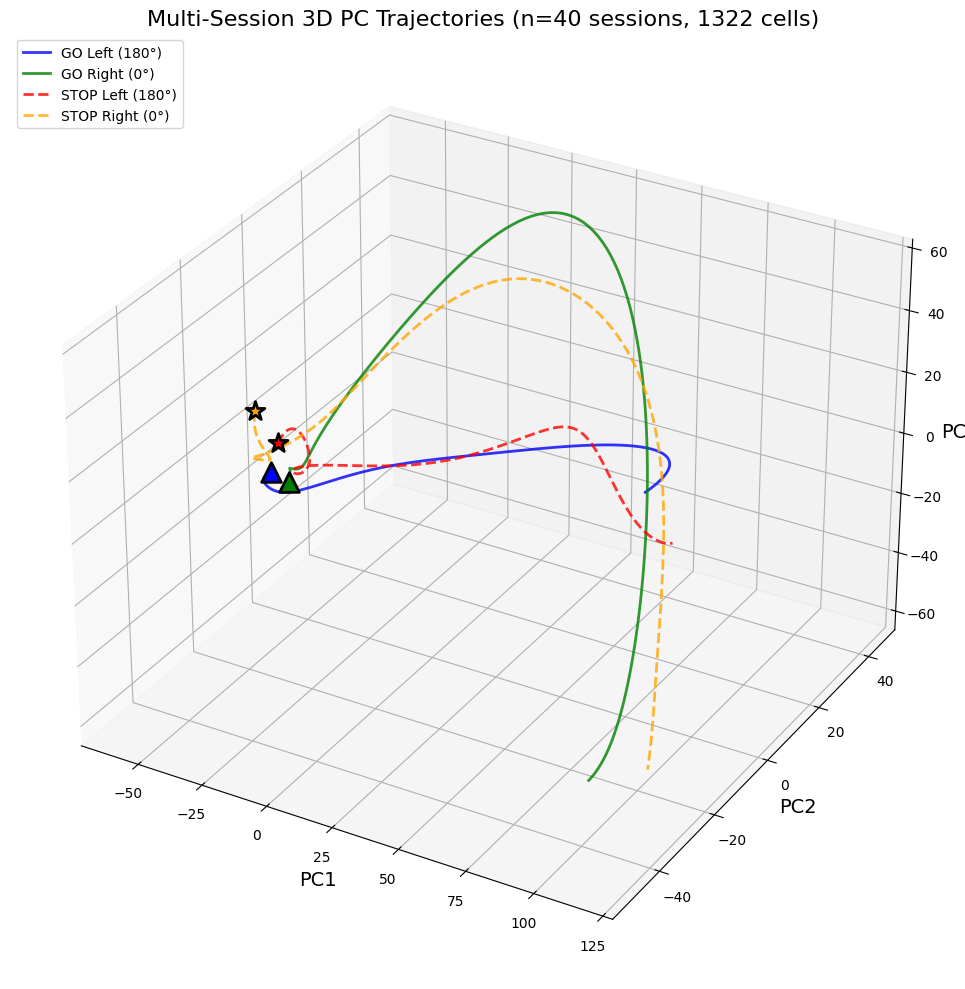

✓ 3D trajectory plot saved


In [21]:
# 3D Trajectory Plot
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=FIGSIZE_3D)
ax = fig.add_subplot(111, projection='3d')

# GO trajectories
ax.plot(go_left_PCs[0, :], go_left_PCs[1, :], go_left_PCs[2, :], 
        color='blue', linewidth=2, label='GO Left (180°)', alpha=0.8)
ax.plot(go_right_PCs[0, :], go_right_PCs[1, :], go_right_PCs[2, :], 
        color='green', linewidth=2, label='GO Right (0°)', alpha=0.8)

# STOP trajectories
ax.plot(stop_left_PCs[0, :], stop_left_PCs[1, :], stop_left_PCs[2, :], 
        color='red', linewidth=2, label='STOP Left (180°)', linestyle='dashed', alpha=0.8)
ax.plot(stop_right_PCs[0, :], stop_right_PCs[1, :], stop_right_PCs[2, :], 
        color='orange', linewidth=2, label='STOP Right (0°)', linestyle='dashed', alpha=0.8)

# Start markers
ax.scatter(go_left_PCs[0, 0], go_left_PCs[1, 0], go_left_PCs[2, 0], 
          marker='^', s=200, color='blue', edgecolors='black', linewidths=2, zorder=5)
ax.scatter(go_right_PCs[0, 0], go_right_PCs[1, 0], go_right_PCs[2, 0], 
          marker='^', s=200, color='green', edgecolors='black', linewidths=2, zorder=5)
ax.scatter(stop_left_PCs[0, 0], stop_left_PCs[1, 0], stop_left_PCs[2, 0], 
          marker='*', s=200, color='red', edgecolors='black', linewidths=2, zorder=5)
ax.scatter(stop_right_PCs[0, 0], stop_right_PCs[1, 0], stop_right_PCs[2, 0], 
          marker='*', s=200, color='orange', edgecolors='black', linewidths=2, zorder=5)

ax.set_xlabel('PC1', fontsize=14)
ax.set_ylabel('PC2', fontsize=14)
ax.set_zlabel('PC3', fontsize=14)
ax.set_title(f'Multi-Session 3D PC Trajectories (n={len(valid_sessions)} sessions, {combined_psth_matrix.shape[0]} cells)', fontsize=16)
ax.legend(fontsize=10, loc='upper left')

plt.tight_layout()
plt.savefig(output_dir / 'trajectory_3d.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ 3D trajectory plot saved")

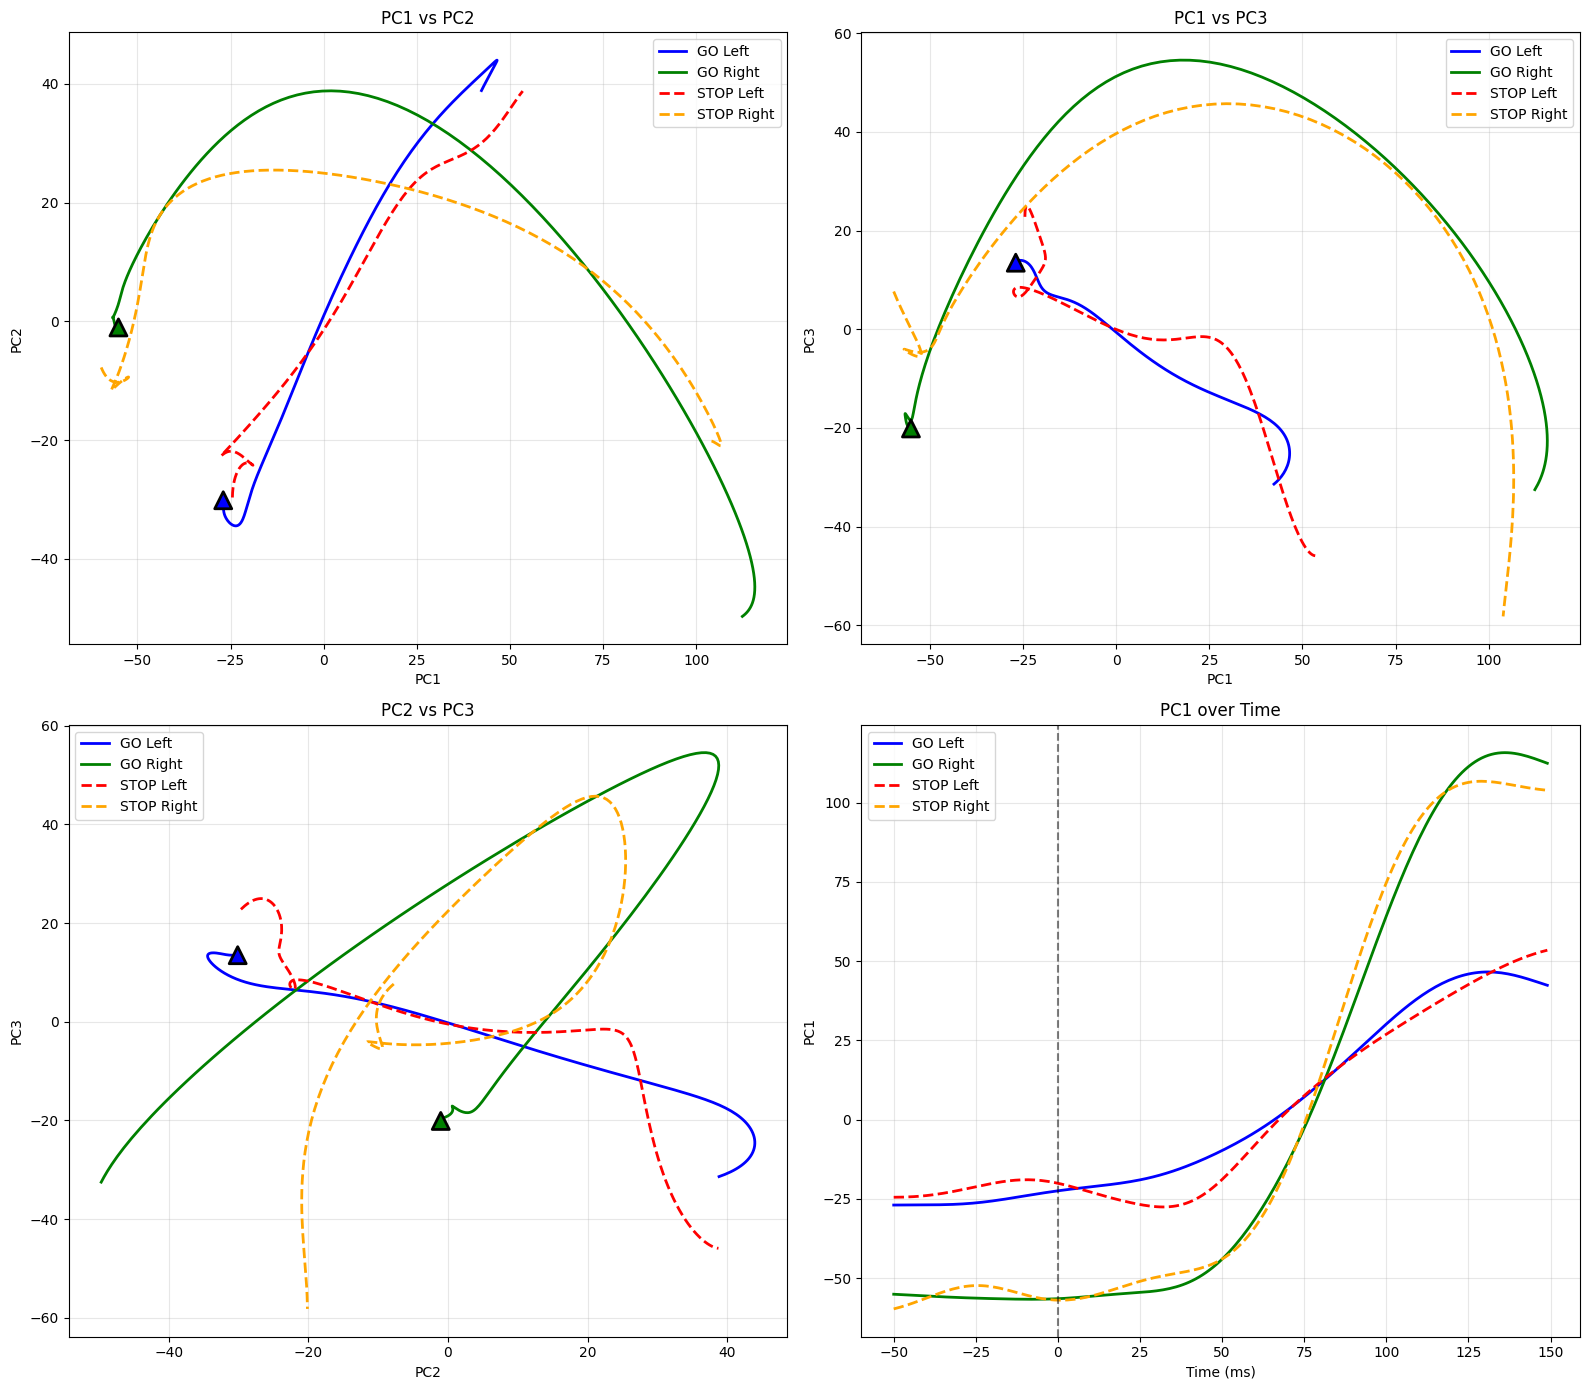

✓ 2D projection grid saved


In [22]:
# 2D Projection Grid
fig, axes = plt.subplots(2, 2, figsize=FIGSIZE_2D_GRID)

# PC1 vs PC2
ax = axes[0, 0]
ax.plot(go_left_PCs[0, :], go_left_PCs[1, :], 'b-', lw=2, label='GO Left')
ax.plot(go_right_PCs[0, :], go_right_PCs[1, :], 'g-', lw=2, label='GO Right')
ax.plot(stop_left_PCs[0, :], stop_left_PCs[1, :], 'r--', lw=2, label='STOP Left')
ax.plot(stop_right_PCs[0, :], stop_right_PCs[1, :], linestyle='--', color='orange', lw=2, label='STOP Right')
ax.scatter([go_left_PCs[0,0], go_right_PCs[0,0]], [go_left_PCs[1,0], go_right_PCs[1,0]], 
          marker='^', s=150, c=['blue', 'green'], edgecolors='black', lw=2, zorder=5)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_title('PC1 vs PC2')
ax.legend(); ax.grid(True, alpha=0.3)

# PC1 vs PC3
ax = axes[0, 1]
ax.plot(go_left_PCs[0, :], go_left_PCs[2, :], 'b-', lw=2, label='GO Left')
ax.plot(go_right_PCs[0, :], go_right_PCs[2, :], 'g-', lw=2, label='GO Right')
ax.plot(stop_left_PCs[0, :], stop_left_PCs[2, :], 'r--', lw=2, label='STOP Left')
ax.plot(stop_right_PCs[0, :], stop_right_PCs[2, :], linestyle='--', color='orange', lw=2, label='STOP Right')
ax.scatter([go_left_PCs[0,0], go_right_PCs[0,0]], [go_left_PCs[2,0], go_right_PCs[2,0]], 
          marker='^', s=150, c=['blue', 'green'], edgecolors='black', lw=2, zorder=5)
ax.set_xlabel('PC1'); ax.set_ylabel('PC3'); ax.set_title('PC1 vs PC3')
ax.legend(); ax.grid(True, alpha=0.3)

# PC2 vs PC3
ax = axes[1, 0]
ax.plot(go_left_PCs[1, :], go_left_PCs[2, :], 'b-', lw=2, label='GO Left')
ax.plot(go_right_PCs[1, :], go_right_PCs[2, :], 'g-', lw=2, label='GO Right')
ax.plot(stop_left_PCs[1, :], stop_left_PCs[2, :], 'r--', lw=2, label='STOP Left')
ax.plot(stop_right_PCs[1, :], stop_right_PCs[2, :], linestyle='--', color='orange', lw=2, label='STOP Right')
ax.scatter([go_left_PCs[1,0], go_right_PCs[1,0]], [go_left_PCs[2,0], go_right_PCs[2,0]], 
          marker='^', s=150, c=['blue', 'green'], edgecolors='black', lw=2, zorder=5)
ax.set_xlabel('PC2'); ax.set_ylabel('PC3'); ax.set_title('PC2 vs PC3')
ax.legend(); ax.grid(True, alpha=0.3)

# PC1 over time
ax = axes[1, 1]
ax.plot(time, go_left_PCs[0, :], 'b-', lw=2, label='GO Left')
ax.plot(time, go_right_PCs[0, :], 'g-', lw=2, label='GO Right')
ax.plot(time, stop_left_PCs[0, :], 'r--', lw=2, label='STOP Left')
ax.plot(time, stop_right_PCs[0, :], linestyle='--', color='orange', lw=2, label='STOP Right')
ax.axvline(x=0, color='black', linestyle='--', alpha=0.5)
ax.set_xlabel('Time (ms)'); ax.set_ylabel('PC1'); ax.set_title('PC1 over Time')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / 'projections_2d_grid.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ 2D projection grid saved")

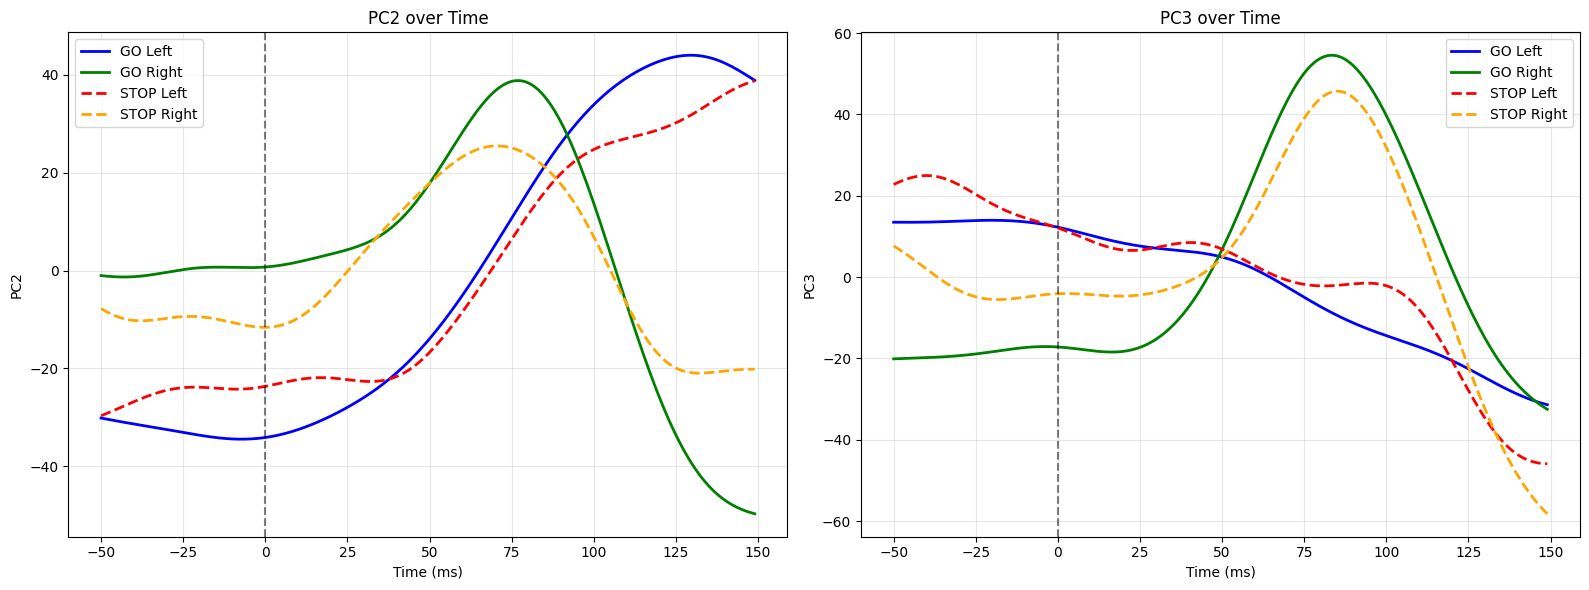

✓ PC time series plots saved


In [23]:
# PC Time Series (PC2 and PC3)
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_TIME)

# PC2
ax = axes[0]
ax.plot(time, go_left_PCs[1, :], 'b-', lw=2, label='GO Left')
ax.plot(time, go_right_PCs[1, :], 'g-', lw=2, label='GO Right')
ax.plot(time, stop_left_PCs[1, :], 'r--', lw=2, label='STOP Left')
ax.plot(time, stop_right_PCs[1, :], linestyle='--', color='orange', lw=2, label='STOP Right')
ax.axvline(x=0, color='black', linestyle='--', alpha=0.5)
ax.set_xlabel('Time (ms)'); ax.set_ylabel('PC2'); ax.set_title('PC2 over Time')
ax.legend(); ax.grid(True, alpha=0.3)

# PC3
ax = axes[1]
ax.plot(time, go_left_PCs[2, :], 'b-', lw=2, label='GO Left')
ax.plot(time, go_right_PCs[2, :], 'g-', lw=2, label='GO Right')
ax.plot(time, stop_left_PCs[2, :], 'r--', lw=2, label='STOP Left')
ax.plot(time, stop_right_PCs[2, :], linestyle='--', color='orange', lw=2, label='STOP Right')
ax.axvline(x=0, color='black', linestyle='--', alpha=0.5)
ax.set_xlabel('Time (ms)'); ax.set_ylabel('PC3'); ax.set_title('PC3 over Time')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / 'pc_timeseries.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ PC time series plots saved")

Session contributions:
session_id
fi211110a    84
fi211026a    76
fi211102a    71
fi211111a    64
fi211025a    63
fi211104a    59
fi211109a    59
fi211122a    58
fi211115a    53
fi211118a    52
fi211020a    49
fi211108a    42
fi211018a    40
fi211123a    36
fi211019a    34
fi211125a    34
fi211014a    32
fi211017a    32
fi211103a    29
fi211021a    27
fi211124a    26
fi210907a    25
fi210909a    23
fi211012a    22
fi211117a    21
fi210728a    19
fi210818a    18
fi210725a    17
fi210823a    16
fi210811a    16
fi210817a    15
fi210819a    14
fi210902a    14
fi210727a    13
fi210812a    13
fi210901a    12
fi210721a    12
fi210726a    11
fi210815a    11
fi210809a    10
Name: count, dtype: int64


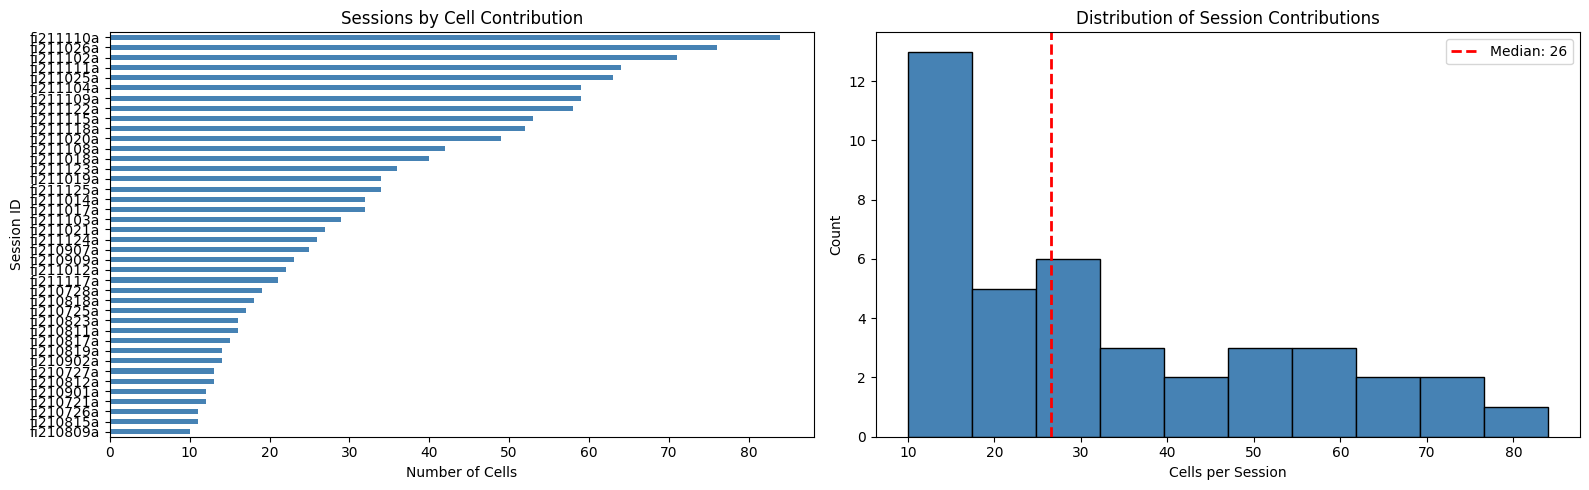


✓ Analysis complete
  Mean: 33.0 cells/session
  Median: 26.5 cells/session


In [24]:
# Session Contributions Analysis
session_contributions = cell_session_df['session_id'].value_counts().sort_values(ascending=False)

print("Session contributions:")
print(session_contributions)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar plot
ax = axes[0]
session_contributions.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Number of Cells')
ax.set_ylabel('Session ID')
ax.set_title('Sessions by Cell Contribution')
ax.invert_yaxis()

# Histogram
ax = axes[1]
ax.hist(session_contributions.values, bins=10, color='steelblue', edgecolor='black')
ax.set_xlabel('Cells per Session')
ax.set_ylabel('Count')
ax.set_title('Distribution of Session Contributions')
ax.axvline(session_contributions.median(), color='red', linestyle='--', lw=2, label=f'Median: {session_contributions.median():.0f}')
ax.legend()

plt.tight_layout()
plt.savefig(output_dir / 'session_contributions.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Analysis complete")
print(f"  Mean: {session_contributions.mean():.1f} cells/session")
print(f"  Median: {session_contributions.median():.1f} cells/session")

In [25]:
# Final Summary
print("=" * 80)
print("MULTI-SESSION PCA ANALYSIS SUMMARY")
print("=" * 80)

print(f"\nData Summary:")
print(f"  Monkey: {MONKEY}")
print(f"  Sessions analyzed: {len(valid_sessions)}")
print(f"  Total cells: {combined_psth_matrix.shape[0]}")

print(f"\nPCA Configuration:")
print(f"  Epoch: {EPOK} ms (relative to {ALIGNMENT_POINT})")
print(f"  Bin size: {BIN_SIZE} ms")
print(f"  Smoothing: {SMOOTH_KER_SIZE} ms")
print(f"  Components: {N_PCA_COMPONENTS}")

print(f"\nPCA Results:")
for i, var in enumerate(pca.explained_variance_ratio_, 1):
    print(f"  PC{i}: {var*100:.2f}% variance")
print(f"  Total: {pca.explained_variance_ratio_.sum()*100:.2f}%")

print(f"\nOutput: {output_dir}")
print("=" * 80)

MULTI-SESSION PCA ANALYSIS SUMMARY

Data Summary:
  Monkey: fiona
  Sessions analyzed: 40
  Total cells: 1322

PCA Configuration:
  Epoch: [-50, 150] ms (relative to go_cue)
  Bin size: 1 ms
  Smoothing: 15 ms
  Components: 5

PCA Results:
  PC1: 55.30% variance
  PC2: 15.93% variance
  PC3: 9.98% variance
  PC4: 5.32% variance
  PC5: 3.20% variance
  Total: 89.73%

Output: /Users/barak/Projects/population_analysis/data/PCA_data/multi_session
